In [3]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

## Define State

In [4]:
class TemperatureState(TypedDict):
    temp_celsius: float
    temp_fahrenheit: float


### convert temp function

In [5]:
def convert_temp(state: TemperatureState) -> TemperatureState:
    celsius = state['temp_celsius']
    fahrenheit = (celsius * 9/5) + 32
    state['temp_fahrenheit'] = round(fahrenheit, 2)  # round to 2 decimal places for fahrenheit
    return state

### define and compile graph

In [ ]:
## define graph
graph = StateGraph(TemperatureState)


## add nodes
graph.add_node('convert_temp', convert_temp)


## add edges to the graph
graph.add_edge(START, 'convert_temp')
graph.add_edge('convert_temp', END)


## compile the graph
workflow = graph.compile()

### execute graph

In [11]:
initial_state = {'temp_celsius': 28.5}
final_state =  workflow.invoke(initial_state)
print(final_state)  

{'temp_celsius': 28.5, 'temp_fahrenheit': 83.3}


## visualize graph

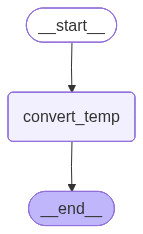

In [13]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())